## Figure 2 — Inter-species Contamination & Ambient RNA Removal Performance

Evaluates ambient RNA removal tools (CellBender, SoupX, DecontX, scAR, CellClear) 
across six human-mouse mixture (hgmm) 10x Genomics datasets of increasing cell counts.

### Required files (all under `figure_2_data/`)
- `interspecies_contamination/hgmm{1k,5k,6k,10k,12k,20k}_count_ratio_uncorrected.csv`  
  Per-cell cross-species count ratios (uncorrected) → **Fig_2A only**
- `hgmm{1k,5k,6k,10k,12k,20k}_data.csv`  
  Per-tool per-dataset aggregated count metrics → **Fig_2B, 2C, 2D**
- `mixture_data.csv`  
  Summary table used for pairwise statistical tests → **significance brackets in Fig_2C**

### Figures produced
- **Fig_2A** — Boxplot of per-cell cross-species contamination ratios before correction
- **Fig_2B** — Intra-species removal (observed/expected) per tool and dataset
- **Fig_2C** — Sensitivity vs. total count removal scatter with zoomed inset and significance brackets
- **Fig_2D** — Summary metrics table (sensitivity, consistency, precision, specificity, intra-species ratio)

> Note: 1k dataset is excluded from aggregated metrics (Fig_2C, 2D) due to near-zero contamination levels.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from itertools import combinations
from scipy import stats
from matplotlib.patches import ConnectionPatch, Rectangle
plt.rcParams['font.family'] = 'Arial'

DATASETS  = ['1k', '5k', '6k', '10k', '12k', '20k']
DS_ORDER  = DATASETS
TOOL_COLORS = {
    'CellBender': '#2E86AB', 'DecontX': '#A23B72',
    'SoupX': '#F18F01',      'scCDC' : '#3BB273' ,
    'scAR':    '#C73E1D',    'CellClear': '#6A4C93', 
}
DS_MARKERS = {'1k':'o','5k':'s','6k':'^','10k':'D','12k':'v','20k':'P'}

In [2]:
# Fig_2A source: per-cell cross-species count ratios
dfs_a = []
for d in DATASETS:
    df = pd.read_csv(Path('interspecies_contamination') / f'hgmm{d}_count_ratio_uncorrected.csv', index_col=0)
    df['dataset'] = d
    dfs_a.append(df)
data_a = pd.concat(dfs_a)

# Assign contamination direction per cell
human_c = data_a[data_a['species_refined']=='human'].assign(
    contam=lambda x: x['mouse count ratio'], direction='mouse-in-human')
mouse_c = data_a[data_a['species_refined']=='mouse'].assign(
    contam=lambda x: x['human count ratio'], direction='human-in-mouse')
contam = pd.concat([human_c[['dataset','contam','direction']],
                    mouse_c[['dataset','contam','direction']]])

# Fig_2B/C/D source: aggregated per-tool per-dataset counts
dfs_b = []
for d in DATASETS:
    df = pd.read_csv(Path('figure_2_data') / f'hgmm{d}_data.csv', index_col=0)
    df['dataset'] = d
    dfs_b.append(df)
data_b = pd.concat(dfs_b)

# Uncorrected baseline + expected intra-species ambient (by symmetry assumption)
unc = data_b[data_b['Tool'] == 'Uncorrected'].copy()
unc['total_human']   = unc['hg in hg unc'] + unc['mm in hg unc']
unc['total_mouse']   = unc['mm in mm unc'] + unc['hg in mm unc']
unc['expected_hg_B'] = (unc['hg in mm unc'] / unc['total_mouse']) * unc['total_human']
unc['expected_mm_B'] = (unc['mm in hg unc'] / unc['total_human']) * unc['total_mouse']
unc['known_ambient'] = unc['hg in mm unc'] + unc['mm in hg unc']
unc['expected_ambient'] = unc['known_ambient'] + unc['expected_hg_B'] + unc['expected_mm_B']

corr = data_b[data_b['Tool'] != 'Uncorrected'].copy()
corr = corr.merge(unc[['dataset','known_ambient','expected_ambient',
                        'expected_hg_B','expected_mm_B']], on='dataset')

In [11]:
# per dataset values for supplement
supp_cols = ['Tool', 'dataset', 'sensitivity', 'precision_extrap', 'specificity', 
             'pct removed counts', 'intra_geomean']

supp_table = (corr[supp_cols]
              .rename(columns={
                  'dataset':           'Dataset',
                  'sensitivity':       'Sensitivity (%)',
                  'precision_extrap':  'Precision, extrapolated (%)',
                  'specificity':       'Specificity (%)',
                  'pct removed counts':'Total removed (%)',
                  'intra_geomean':     'Intra-species ratio (geom. mean)'
              })
              .sort_values(['Tool', 'Dataset'])
              .round(1)
              .assign(Note=lambda df: df['Dataset'].map(lambda d: '1k excluded from aggregates' if d == '1k' else ''))
)

supp_table

,Tool,Dataset,Sensitivity (%),"Precision, extrapolated (%)",Specificity (%),Total removed (%),Intra-species ratio (geom. mean),Note
21,CellBender,10k,97.3,96.4,99.9,2.1,1.0,
27,CellBender,12k,92.6,99.5,100.0,2.4,0.6,
3,CellBender,1k,93.3,56.5,99.7,0.7,2.5,1k excluded from aggregates
33,CellBender,20k,94.9,99.4,100.0,2.2,0.7,
9,CellBender,5k,94.9,100.0,100.0,1.5,0.5,
15,CellBender,6k,90.2,100.0,100.0,1.6,0.5,
22,CellClear,10k,85.8,5.4,60.2,41.1,36.6,
28,CellClear,12k,88.4,9.0,62.9,39.3,23.8,
4,CellClear,1k,85.2,1.2,62.4,37.9,136.7,1k excluded from aggregates
34,CellClear,20k,74.7,6.8,66.8,34.7,24.8,


In [4]:
df_mix = pd.read_csv('figure_2_data/mixture_data.csv')
df_long = df_mix.melt(id_vars=['Tool'], var_name='column', value_name='percentage')
df_long[['dataset','metric']] = df_long['column'].str.extract(r'(\d+k|mean|std)\s+(ambient|total)')
df_long = df_long.drop(columns=['column']).dropna()

tools_to_compare = ['DecontX', 'SoupX', 'CellBender', 'scCDC']
df_stats = df_long[df_long['Tool'].isin(tools_to_compare) &
                   ~df_long['dataset'].isin(['mean','std'])].copy()

for test_name, test_fn in [('paired t-test', stats.ttest_rel),
                            ('wilcoxon',      stats.wilcoxon)]:
    results = []
    for metric in ['ambient', 'total']:
        pivot = df_stats[df_stats['metric']==metric].pivot(
            index='dataset', columns='Tool', values='percentage')
        for t1, t2 in combinations(tools_to_compare, 2):
            stat, p = test_fn(pivot[t1], pivot[t2])
            results.append({'metric': metric, 'comparison': f'{t1} vs {t2}',
                            'mean_diff': pivot[t1].mean() - pivot[t2].mean(),
                            'statistic': stat, 'p_value': p,
                            'sig': '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'})
    print(f"\n{test_name}:")
    print(pd.DataFrame(results).to_string(index=False))


paired t-test:
 metric            comparison  mean_diff  statistic  p_value sig
ambient      DecontX vs SoupX -18.174629  -1.604691 0.169468  ns
ambient DecontX vs CellBender -38.071243  -6.165320 0.001634  **
ambient      DecontX vs scCDC  36.216750   5.129568 0.003677  **
ambient   SoupX vs CellBender -19.896613  -2.775657 0.039103   *
ambient        SoupX vs scCDC  54.391379   6.104837 0.001708  **
ambient   CellBender vs scCDC  74.287993  20.042390 0.000006 ***
  total      DecontX vs SoupX  -0.607117  -1.462880 0.203363  ns
  total DecontX vs CellBender  -0.313661  -2.118544 0.087667  ns
  total      DecontX vs scCDC  -1.372330  -3.207445 0.023796   *
  total   SoupX vs CellBender   0.293456   0.810347 0.454565  ns
  total        SoupX vs scCDC  -0.765213  -2.756296 0.040010   *
  total   CellBender vs scCDC  -1.058669  -2.277484 0.071764  ns

wilcoxon:
 metric            comparison  mean_diff  statistic  p_value sig
ambient      DecontX vs SoupX -18.174629        4.0  0.21875  n

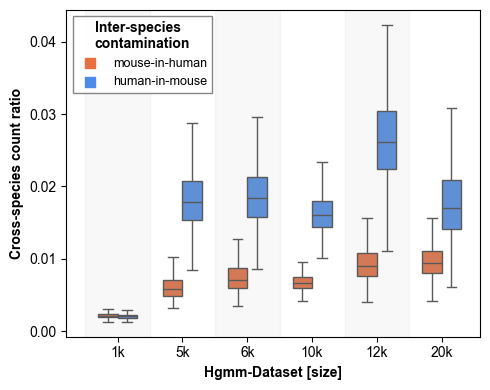

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
for i in range(len(DS_ORDER)):
    if i % 2 == 0:
        ax.axvspan(i - 0.5, i + 0.5, color='gray', alpha=0.05, zorder=0)

sns.boxplot(data=contam, x='dataset', y='contam', hue='direction',
            order=DS_ORDER, showfliers=False,
            palette=['#E87040', '#4C8BE8'], ax=ax, width=0.6)

species_leg = [plt.scatter([], [], color=c, marker='s', s=50, label=s)
               for s, c in {'mouse-in-human':'#E87040','human-in-mouse':'#4C8BE8'}.items()]
leg = ax.legend(handles=species_leg, loc='upper left', title='Inter-species\ncontamination',
                fontsize=9, frameon=True, fancybox=False, edgecolor='gray', framealpha=0.95)
leg.get_title().set_fontsize(10); leg.get_title().set_fontweight('bold')

ax.set_ylabel('Cross-species count ratio', weight='bold')
ax.set_xlabel('Hgmm-Dataset [size]', weight='bold')
plt.tight_layout()
plt.savefig('Fig_2A.png', dpi=300)
plt.show()

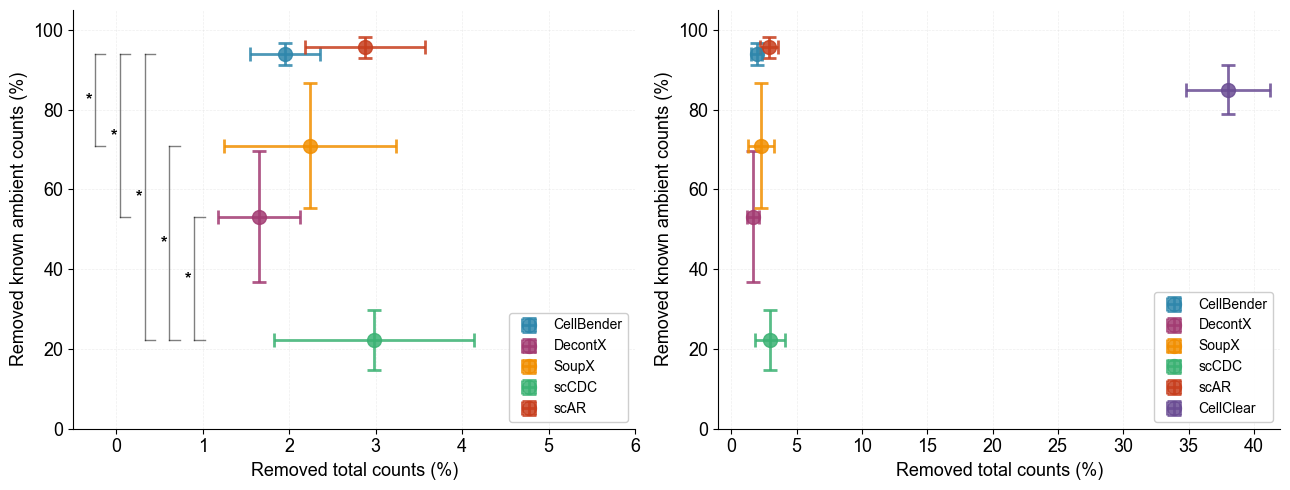

In [6]:
summary = corr[corr['dataset'] != '1k'].groupby('Tool').agg(
    mean_sens=('pct removed true ambient', 'mean'), std_sens=('pct removed true ambient', 'std'),
    mean_rem=('pct removed counts', 'mean'),         std_rem=('pct removed counts', 'std')
).loc[TOOL_COLORS.keys()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

tools_no_cc = [t for t in TOOL_COLORS if t != 'CellClear']

# ── Panel A: zoomed, no CellClear, significance brackets ──────────────────
for tool in tools_no_cc:
    row = summary.loc[tool]
    ax1.errorbar(row.mean_rem, row.mean_sens, xerr=row.std_rem, yerr=row.std_sens,
                 fmt='o', color=TOOL_COLORS[tool], label=tool,
                 capsize=5, markersize=10, capthick=2, elinewidth=2, alpha=0.85, zorder=3)

ax1.set(xlabel='Removed total counts (%)', ylabel='Removed known ambient counts (%)',
        xlim=(-0.5, 6), ylim=(0, 105))
ax1.tick_params(labelsize=13)
ax1.xaxis.label.set_size(13)
ax1.yaxis.label.set_size(13)
ax1.legend(frameon=True, fontsize=10, loc='lower right', framealpha=0.95)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(alpha=0.2, linestyle='--', linewidth=0.5, zorder=0)

def draw_bracket(ax, x, y1, y2, label, x_text_offset=-0.03):
    """Draw a vertical significance bracket at x between y1 (lower) and y2 (upper)."""
    arm = 0.12
    ax.plot([x]*2, [y1, y2], 'k-', lw=1, alpha=0.5)
    for y in [y1, y2]:
        ax.plot([x, x + arm], [y, y], 'k-', lw=1, alpha=0.5)
    ax.text(x + x_text_offset, (y1 + y2) / 2, label,
            ha='right', va='center', fontsize=12, fontweight='bold')

cb = summary.loc['CellBender', 'mean_sens']
dx = summary.loc['DecontX',    'mean_sens']
sx = summary.loc['SoupX',      'mean_sens']
sc = summary.loc['scCDC',      'mean_sens']

draw_bracket(ax1, x=-0.25, y1=sx, y2=cb, label='*')
draw_bracket(ax1, x=0.0375, y1=dx, y2=cb, label='*')
draw_bracket(ax1, x=0.325, y1=sc, y2=cb, label='*')
draw_bracket(ax1, x=0.6125, y1=sc, y2=sx, label='*')
draw_bracket(ax1, x=0.9, y1=sc, y2=dx, label='*')

# ── Panel B: full range, all tools, no brackets ───────────────────────────
for tool, row in summary.iterrows():
    ax2.errorbar(row.mean_rem, row.mean_sens, xerr=row.std_rem, yerr=row.std_sens,
                 fmt='o', color=TOOL_COLORS[tool], label=tool,
                 capsize=5, markersize=10, capthick=2, elinewidth=2, alpha=0.85, zorder=3)

ax2.set(xlabel='Removed total counts (%)', ylabel='Removed known ambient counts (%)',
        ylim=(0, 105), xlim=(-1, 42))
ax2.tick_params(labelsize=13)
ax2.xaxis.label.set_size(13)
ax2.yaxis.label.set_size(13)
ax2.legend(frameon=True, fontsize=10, loc='lower right', framealpha=0.95)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(alpha=0.2, linestyle='--', linewidth=0.5, zorder=0)

fig.tight_layout()
plt.savefig('Fig_2C.png', dpi=300)
plt.show()

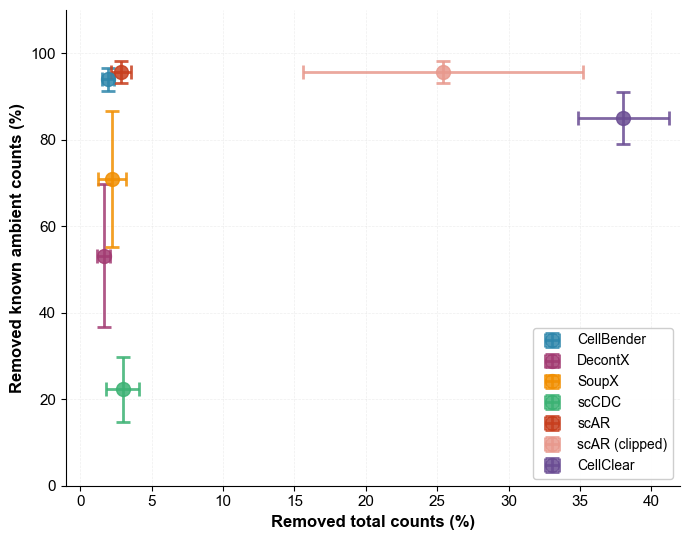

In [7]:
# Supplementary figure including scar_clipped
from scipy import stats as scipy_stats
import numpy as np


# Color palette for tools - added scAR (clipped)
tool_colors = {
    'CellBender': '#2E86AB',
    'DecontX': '#A23B72',
    'SoupX': '#F18F01',
    'scCDC' : '#3BB273' ,
    'scAR': '#C73E1D',
    'scAR (clipped)': '#E8998D',  # lighter version of scAR color
    'CellClear': '#6A4C93',
}

# Hardcode scAR (clipped) values from table
scar_clipped_data = {
    'mean_sens': summary.loc['scAR', 'mean_sens'],  # Same ambient removal as regular scAR
    'std_sens': summary.loc['scAR', 'std_sens'],
    'mean_rem': 25.4,  # From table
    'std_rem': 9.83    # Calculated std
}
summary.loc['scAR (clipped)'] = scar_clipped_data

# Reorder to have scAR (clipped) after scAR
summary = summary.loc[['CellBender', 'DecontX', 'SoupX', 'scCDC', 'scAR', 'scAR (clipped)', 'CellClear']]

fig, ax = plt.subplots(figsize=(7, 5.5))

# Main plot
for tool, row in summary.iterrows():
    ax.errorbar(row.mean_rem, row.mean_sens, xerr=row.std_rem, yerr=row.std_sens,
                fmt='o', color=tool_colors[tool], label=tool,
                capsize=5, markersize=10, capthick=2, elinewidth=2, alpha=0.85, zorder=3)

ax.set_xlabel('Removed total counts (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Removed known ambient counts (%)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 110)
ax.set_xlim(-1, 42)
ax.tick_params(labelsize=11)
ax.legend(frameon=True, fontsize=10, loc='lower right', framealpha=0.95)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2, linestyle='--', linewidth=0.5, zorder=0)

plt.tight_layout()


In [8]:
summary

,mean_sens,std_sens,mean_rem,std_rem
Tool,,,,
CellBender,93.989971,2.668477,1.948753,0.408764
DecontX,53.168834,16.497231,1.643671,0.474259
SoupX,70.946565,15.644513,2.243413,0.994448
scCDC,22.254482,7.522164,2.981755,1.156421
scAR,95.649813,2.571887,2.873550,0.694685
scAR (clipped),95.649813,2.571887,25.400000,9.830000
CellClear,85.059692,6.053417,38.017140,3.187022


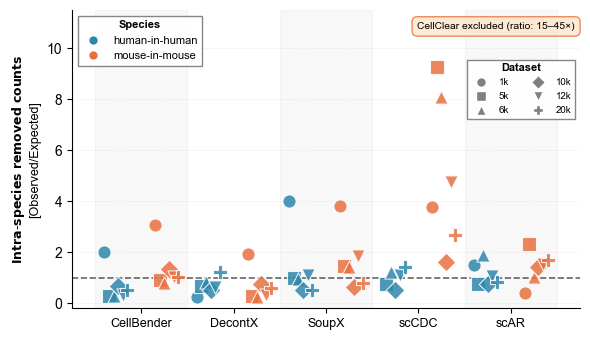

In [9]:
corr['hg_removed'] = corr['hg in hg unc'] - corr['hg in hg corr']
corr['mm_removed'] = corr['mm in mm unc'] - corr['mm in mm corr']
corr['ratio_hg']   = corr['hg_removed'] / corr['expected_hg_B']
corr['ratio_mm']   = corr['mm_removed'] / corr['expected_mm_B']

tool_order = ['CellBender', 'DecontX', 'SoupX', 'scCDC', 'scAR']
plot_df = pd.melt(corr[corr['Tool'].isin(tool_order)][['Tool','dataset','ratio_hg','ratio_mm']],
                  id_vars=['Tool','dataset'], value_vars=['ratio_hg','ratio_mm'],
                  var_name='species', value_name='ratio')
plot_df['species'] = plot_df['species'].map({'ratio_hg':'human-in-human','ratio_mm':'mouse-in-mouse'})

species_colors = {'human-in-human':'#2E86AB', 'mouse-in-mouse':'#E87040'}
human_jitter = {'1k':-0.40,'5k':-0.35,'6k':-0.3,'10k':-0.25,'12k':-0.2,'20k':-0.15}
mouse_jitter = {'1k': 0.15,'5k': 0.20,'6k': 0.25,'10k': 0.30,'12k': 0.35,'20k': 0.40}
tool_pos = {t: i for i, t in enumerate(tool_order)}

fig, ax = plt.subplots(figsize=(6, 3.5))
for i in range(len(tool_order)):
    if i % 2 == 0:
        ax.axvspan(i-0.5, i+0.5, color='gray', alpha=0.05, zorder=0)

for ds in DS_ORDER:
    for species, jitter_map in [('human-in-human', human_jitter), ('mouse-in-mouse', mouse_jitter)]:
        sub = plot_df[(plot_df['species']==species) & (plot_df['dataset']==ds)]
        for _, row in sub.iterrows():
            ax.scatter(tool_pos[row['Tool']] + jitter_map[ds], row['ratio'],
                       color=species_colors[species], marker=DS_MARKERS[ds],
                       s=90, alpha=0.85, zorder=3, edgecolors='white', linewidths=0.8)

ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, alpha=0.6, zorder=2)
ax.grid(axis='y', alpha=0.2, linestyle='--', linewidth=0.5, zorder=0)

species_leg = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=7, label=s)
               for s, c in species_colors.items()]
ds_leg = [plt.Line2D([0],[0], marker=m, color='w', markerfacecolor='gray', markersize=7, label=ds)
          for ds, m in DS_MARKERS.items()]

leg1 = ax.legend(handles=species_leg, loc='upper left', title='Species',
                 fontsize=8, frameon=True, fancybox=False, edgecolor='gray', framealpha=0.95)
leg1.get_title().set_fontsize(8); leg1.get_title().set_fontweight('bold')
ax.add_artist(leg1)
leg2 = ax.legend(handles=ds_leg, loc='upper right', title='Dataset',
                 fontsize=7, ncol=2, frameon=True, fancybox=False, edgecolor='gray',
                 framealpha=0.95, bbox_to_anchor=(1.0,0.85))
leg2.get_title().set_fontsize(8); leg2.get_title().set_fontweight('bold')

ax.set_xticks(range(len(tool_order))); ax.set_xticklabels(tool_order, fontsize=9)
ax.set_ylabel(r'$\bf{Intra\text{-}species\ removed\ counts}$' + '\n[Observed/Expected]', fontsize=9)
ax.set_ylim(-0.2, 11.5)
ax.text(0.99, 0.96, 'CellClear excluded (ratio: 15–45×)', transform=ax.transAxes,
        ha='right', va='top', fontsize=7.5,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFE5CC', edgecolor='#E87040', alpha=0.8))
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('Fig_2B.png', dpi=300)
plt.show()

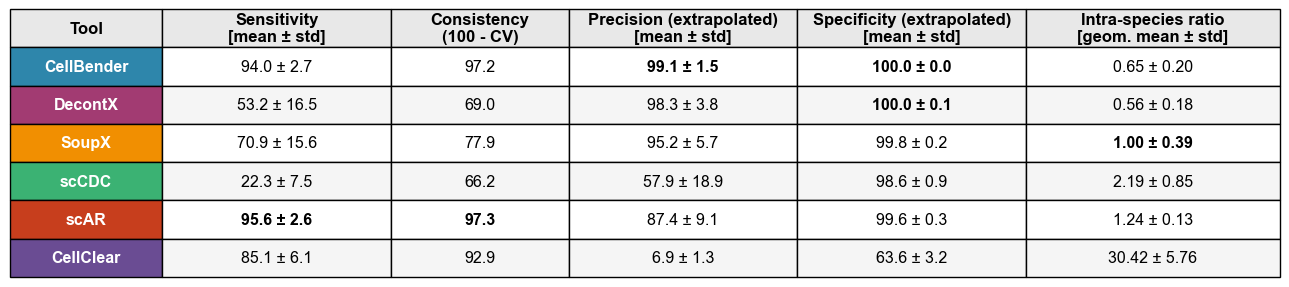

In [10]:
# Use CSV columns directly for sensitivity and removal counts
corr['sensitivity']    = corr['pct removed true ambient']
corr['removed_counts'] = corr['removed counts']
corr['known_removed']  = corr['removed true ambient']

corr['hg_removed'] = corr['hg in hg unc'] - corr['hg in hg corr']
corr['mm_removed'] = corr['mm in mm unc'] - corr['mm in mm corr']
corr['ratio_hg']   = corr['hg_removed'] / corr['expected_hg_B']
corr['ratio_mm']   = corr['mm_removed'] / corr['expected_mm_B']
corr['intra_geomean']    = (corr['ratio_hg'] * corr['ratio_mm']) ** 0.5
corr['intra_TP_hg']      = corr['hg_removed'].clip(upper=corr['expected_hg_B'])
corr['intra_TP_mm']      = corr['mm_removed'].clip(upper=corr['expected_mm_B'])
corr['total_TP']         = corr['known_removed'] + corr['intra_TP_hg'] + corr['intra_TP_mm']
corr['precision_extrap'] = (corr['total_TP'] / corr['removed_counts'] * 100).clip(upper=100)
corr['FP_hg']      = (corr['hg_removed'] - corr['expected_hg_B']).clip(lower=0)
corr['FP_mm']      = (corr['mm_removed'] - corr['expected_mm_B']).clip(lower=0)
corr['FP']         = corr['FP_hg'] + corr['FP_mm']
corr['TN']         = (corr['total counts unc'] - corr['expected_ambient']) - corr['FP']
corr['specificity'] = (corr['TN'] / (corr['TN'] + corr['FP']) * 100).clip(lower=0, upper=100)

corr['sensitivity'] = corr['pct removed true ambient']
corr_e = corr[corr['dataset'] != '1k']
tool_order_full = ['CellBender', 'DecontX', 'SoupX',  'scCDC', 'scAR', 'CellClear']

rows = []
for tool in tool_order_full:
    sub = corr_e[corr_e['Tool'] == tool]
    sens_m, sens_s = sub['sensitivity'].mean(), sub['sensitivity'].std()
    rows.append({
        'Tool': tool,
        'Sensitivity\n[mean ± std]':            f'{sens_m:.1f} ± {sens_s:.1f}',
        'Consistency\n(100 - CV)':              f'{100 - sens_s/sens_m*100:.1f}',
        'Precision (extrapolated)\n[mean ± std]': f'{sub["precision_extrap"].mean():.1f} ± {sub["precision_extrap"].std():.1f}',
        'Specificity (extrapolated)\n[mean ± std]': f'{sub["specificity"].mean():.1f} ± {sub["specificity"].std():.1f}',
        'Intra-species ratio\n[geom. mean ± std]': f'{sub["intra_geomean"].mean():.2f} ± {sub["intra_geomean"].std():.2f}',
    })
df_metrics = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(13, 3))
ax.axis('off')
table = ax.table(cellText=df_metrics.values, colLabels=df_metrics.columns,
                 cellLoc='center', loc='center',
                 colWidths=[0.12, 0.18, 0.14, 0.18, 0.18, 0.20])
table.auto_set_font_size(False); table.set_fontsize(11.5); table.scale(1, 2.4)

for i in range(1, len(df_metrics)+1):
    if i % 2 == 0:
        for j in range(len(df_metrics.columns)):
            table[(i,j)].set_facecolor('#F5F5F5')
for i, tool in enumerate(df_metrics['Tool']):
    table[(i+1, 0)].set_facecolor(TOOL_COLORS[tool])
    table[(i+1, 0)].set_text_props(weight='bold', color='white')
for j in range(len(df_metrics.columns)):
    table[(0,j)].set_facecolor('#E8E8E8')
    table[(0,j)].set_text_props(weight='bold', fontsize=12)

# Bold best value per column (closest to 1 for intra-species, highest otherwise)
for j in range(1, len(df_metrics.columns)):
    vals = [(i, float(table[(i,j)].get_text().get_text().split('±')[0])) for i in range(1, len(df_metrics)+1)]
    best = min(vals, key=lambda x: abs(x[1]-1))[1] if j == len(df_metrics.columns)-1 \
           else max(vals, key=lambda x: x[1])[1]
    for i, v in vals:
        if (abs(v-1) == abs(best-1)) if j == len(df_metrics.columns)-1 else v == best:
            table[(i,j)].set_text_props(weight='bold')

plt.tight_layout()
plt.savefig('Fig_2D.png', dpi=300)
plt.show()